# Travel Reimbursement Approval Agent — Using OpenAI

This notebook is a runnable prototype for the **Travel Reimbursement Approval Agent** assignment.

### Design
- **OpenAI Responses API** for agentic tool calling
- **Python deterministic tools** for policy checks and calculations
- **Conservative decision validator** for reliability
- **Structured JSON output** with the exact required fields
- **Audit trail** of tools called by the model and fallback validator
- **Dashboard** generated from actual claim outcomes

> Note: There is no hard-coded API key. Set `OPENAI_API_KEY` in the environment before running.


## 1. Setup / README

### Install
Run the next cell once.

### API key
Recommended on Git Bash / macOS / Linux:

```bash
export OPENAI_API_KEY="your-key"
```

On Windows Command Prompt:

```bat
set OPENAI_API_KEY=your-key
```

On PowerShell:

```powershell
$env:OPENAI_API_KEY="your-key"
```

The notebook also offers a hidden `getpass()` prompt if the variable is not set.

### Model
Default: `gpt-4.1-mini` because it supports the Responses API, function calling, and structured workflows.  
Override with an environment variable:

```bash
export OPENAI_MODEL="gpt-4.1-mini"
```


In [14]:
%pip install -q "openai>=2.0.0" pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import os
import re
from copy import deepcopy
from datetime import datetime
from getpass import getpass
from typing import Any, Dict, List

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

print("Imports successful")


✓ Imports successful


In [15]:
# Never hard-code the API key in the notebook.
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY is required.")

MODEL_NAME = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")

client = OpenAI(api_key=OPENAI_API_KEY)

print(f"OpenAI client initialized. Model: {MODEL_NAME}")


OpenAI client initialized. Model: gpt-4.1-mini


## 2. Policy

The policy is represented as deterministic configuration with stable `POL-*` references.


In [4]:
POLICIES = {
    "categories": {
        "eligible": {
            "id": "POL-CAT-01",
            "items": [
                "airfare",
                "lodging",
                "meals",
                "ground_transport",
                "conference_fees",
            ],
        },
        "ineligible": {
            "id": "POL-CAT-02",
            "items": [
                "alcohol",
                "minibar",
                "spa",
                "gym",
                "entertainment",
                "movies",
                "shopping",
                "gifts",
                "fines",
                "penalties",
                "late_fees",
                "personal",
            ],
        },
    },
    "limits": {
        "meals": {
            "id": "POL-PD-01",
            "max_per_day": 75.0,
        },
        "lodging": {
            "id": "POL-PD-02",
            "max_per_night": 200.0,
        },
        "ground_transport": {
            "id": "POL-PD-03",
            "max_per_day": 50.0,
        },
        "airfare_class": {
            "id": "POL-AIR-01",
            "allowed_class": "economy",
        },
    },
    "receipts": {
        "required": {
            "id": "POL-RCT-01",
            "threshold": 25.0,
            "always_required": ["airfare", "lodging"],
        },
        "missing_handling": {
            "id": "POL-RCT-02",
            "action": "manual_review",
        },
    },
    "approval_tiers": {
        "auto_approve": {
            "id": "POL-APR-01",
            "max": 500.0,
            "action": "approvable",
        },
        "manager": {
            "id": "POL-APR-02",
            "min_exclusive": 500.0,
            "max": 2000.0,
            "action": "approvable",
        },
        "director": {
            "id": "POL-APR-03",
            "min_exclusive": 2000.0,
            "action": "manual_review",
        },
    },
    "timeliness": {
        "id": "POL-TIME-01",
        "max_days": 30,
    },
}

print("Policy loaded")


✓ Policy loaded


## 3. Sample Claims

The five claims provided in the assignment.


In [5]:
SAMPLE_CLAIMS = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip_dates": {"start": "2026-06-10", "end": "2026-06-12"},
        "submission_date": "2026-06-20",
        "description": "Attend 2-day industry conference (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": True},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": True},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": True},
        ],
        "total_claimed": 1110.00,
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip_dates": {"start": "2026-06-14", "end": "2026-06-15"},
        "submission_date": "2026-06-25",
        "description": "Weekend hotel stay",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True},
        ],
        "total_claimed": 380.00,
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip_dates": {"start": "2026-06-08", "end": "2026-06-10"},
        "submission_date": "2026-06-22",
        "description": "Client site visit (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": True},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": True},
        ],
        "total_claimed": 940.00,
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip_dates": {"start": "2026-06-16", "end": "2026-06-18"},
        "submission_date": "2026-06-28",
        "description": "International vendor negotiation (business)",
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": False},
        ],
        "total_claimed": 3000.00,
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip_dates": {"start": "2026-06-11", "end": "2026-06-11"},
        "submission_date": "2026-06-24",
        "description": "Client dinner / business development",
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": False},
        ],
        "total_claimed": 220.00,
    },
]

print(f"Loaded sample claims")


✓ Loaded 5 sample claims


## 4. Deterministic Tools

The LLM can decide which tools to call.  
All financial calculations and policy rules are executed in Python.


In [6]:
def _norm_category(value: str) -> str:
    return (value or "").strip().lower().replace(" ", "_")


def _trip_days(trip_dates: Dict[str, str]) -> int:
    start = datetime.strptime(trip_dates["start"], "%Y-%m-%d")
    end = datetime.strptime(trip_dates["end"], "%Y-%m-%d")
    return max((end - start).days + 1, 1)


def _trip_nights(trip_dates: Dict[str, str]) -> int:
    start = datetime.strptime(trip_dates["start"], "%Y-%m-%d")
    end = datetime.strptime(trip_dates["end"], "%Y-%m-%d")
    return max((end - start).days, 1)


def _extract_count(description: str, unit: str, fallback: int) -> int:
    match = re.search(rf"(\d+)\s*{unit}", description or "", flags=re.IGNORECASE)
    return int(match.group(1)) if match else fallback


def check_eligibility(items: List[Dict[str, Any]]) -> Dict[str, Any]:
    eligible_set = set(POLICIES["categories"]["eligible"]["items"])
    ineligible_terms = POLICIES["categories"]["ineligible"]["items"]

    eligible, ineligible, unknown = [], [], []

    for item in items:
        category = _norm_category(item.get("category", ""))
        description = (item.get("description") or "").lower()
        haystack = f"{category} {description}"

        if category in eligible_set:
            eligible.append(item)
        elif category in ineligible_terms or any(term in haystack for term in ineligible_terms):
            ineligible.append(item)
        else:
            unknown.append(item)

    return {
        "eligible_count": len(eligible),
        "ineligible_count": len(ineligible),
        "unknown_count": len(unknown),
        "eligible_categories": [_norm_category(x.get("category")) for x in eligible],
        "ineligible_categories": [_norm_category(x.get("category")) for x in ineligible],
        "unknown_categories": [_norm_category(x.get("category")) for x in unknown],
        "policy_refs": ["POL-CAT-01", "POL-CAT-02"],
    }


def check_receipts(items: List[Dict[str, Any]]) -> Dict[str, Any]:
    threshold = POLICIES["receipts"]["required"]["threshold"]
    always_required = set(POLICIES["receipts"]["required"]["always_required"])

    missing_docs = []
    required_count = 0

    for item in items:
        category = _norm_category(item.get("category"))
        amount = float(item.get("amount", 0))
        requires = amount > threshold or category in always_required

        if requires:
            required_count += 1
            if not bool(item.get("receipt_attached", False)):
                missing_docs.append(f"Itemized receipt for {category} (${amount:.2f})")

    refs = ["POL-RCT-01"]
    if missing_docs:
        refs.append("POL-RCT-02")

    return {
        "required_receipts": required_count,
        "missing_count": len(missing_docs),
        "missing_docs": missing_docs,
        "requires_manual_review": bool(missing_docs),
        "policy_refs": refs,
    }


def apply_limits(items: List[Dict[str, Any]], trip_dates: Dict[str, str]) -> Dict[str, Any]:
    eligible_set = set(POLICIES["categories"]["eligible"]["items"])
    ineligible_terms = POLICIES["categories"]["ineligible"]["items"]

    approved_total = 0.0
    deducted_total = 0.0
    adjustments = []
    refs = set()

    for item in items:
        category = _norm_category(item.get("category"))
        description = item.get("description", "")
        amount = float(item.get("amount", 0.0))
        haystack = f"{category} {description.lower()}"

        # Never reimburse explicitly ineligible items.
        if category in ineligible_terms or any(term in haystack for term in ineligible_terms):
            deducted_total += amount
            adjustments.append({
                "category": category,
                "claimed": amount,
                "allowed": 0.0,
                "deducted": amount,
                "reason": "Ineligible expense category",
            })
            refs.add("POL-CAT-02")
            continue

        # Unknown categories are left unresolved for Manual Review.
        if category not in eligible_set:
            adjustments.append({
                "category": category,
                "claimed": amount,
                "allowed": 0.0,
                "deducted": 0.0,
                "reason": "Unknown category; unresolved pending Manual Review",
            })
            continue

        refs.add("POL-CAT-01")

        if category == "meals":
            days = _extract_count(description, r"days?", _trip_days(trip_dates))
            cap = POLICIES["limits"]["meals"]["max_per_day"] * days
            allowed = min(amount, cap)
            deducted = max(amount - allowed, 0.0)
            refs.add("POL-PD-01")

        elif category == "lodging":
            nights = _extract_count(description, r"nights?", _trip_nights(trip_dates))
            cap = POLICIES["limits"]["lodging"]["max_per_night"] * nights
            allowed = min(amount, cap)
            deducted = max(amount - allowed, 0.0)
            refs.add("POL-PD-02")

        elif category == "ground_transport":
            days = _extract_count(description, r"days?", _trip_days(trip_dates))
            cap = POLICIES["limits"]["ground_transport"]["max_per_day"] * days
            allowed = min(amount, cap)
            deducted = max(amount - allowed, 0.0)
            refs.add("POL-PD-03")

        else:
            allowed = amount
            deducted = 0.0

        approved_total += allowed
        deducted_total += deducted

        if deducted > 0:
            adjustments.append({
                "category": category,
                "claimed": round(amount, 2),
                "allowed": round(allowed, 2),
                "deducted": round(deducted, 2),
                "reason": "Policy cap or eligibility adjustment",
            })

    return {
        "approved_total": round(approved_total, 2),
        "deducted_total": round(deducted_total, 2),
        "adjustments": adjustments,
        "policy_refs": sorted(refs),
    }


def check_airfare_class(items: List[Dict[str, Any]]) -> Dict[str, Any]:
    violations = []

    for item in items:
        category = _norm_category(item.get("category"))
        description = (item.get("description") or "").lower()

        if category == "airfare":
            if any(term in description for term in ["business-class", "business class", "first-class", "first class"]):
                violations.append({
                    "category": category,
                    "amount": float(item.get("amount", 0.0)),
                    "reason": "Non-economy airfare is a policy exception",
                })

    return {
        "has_exception": bool(violations),
        "violations": violations,
        "requires_manual_review": bool(violations),
        "policy_refs": ["POL-AIR-01"],
    }


def check_timeliness(expense_date: str, submission_date: str) -> Dict[str, Any]:
    try:
        expense = datetime.strptime(expense_date, "%Y-%m-%d")
        submitted = datetime.strptime(submission_date, "%Y-%m-%d")
    except ValueError as exc:
        return {
            "is_timely": False,
            "days_since_expense": None,
            "requires_manual_review": True,
            "error": str(exc),
            "policy_refs": ["POL-TIME-01"],
        }

    days = (submitted - expense).days
    is_timely = 0 <= days <= POLICIES["timeliness"]["max_days"]

    return {
        "is_timely": is_timely,
        "days_since_expense": days,
        "requires_manual_review": not is_timely,
        "policy_refs": ["POL-TIME-01"],
    }


def check_approval_tier(total_amount: float) -> Dict[str, Any]:
    total_amount = round(float(total_amount), 2)

    if total_amount <= 500:
        return {
            "tier": "AUTO_APPROVE",
            "action": "approvable",
            "policy_refs": ["POL-APR-01"],
        }

    if total_amount <= 2000:
        return {
            "tier": "MANAGER",
            "action": "approvable",
            "policy_refs": ["POL-APR-02"],
        }

    return {
        "tier": "DIRECTOR",
        "action": "manual_review",
        "policy_refs": ["POL-APR-03"],
    }


TOOL_FUNCTIONS = {
    "check_eligibility": check_eligibility,
    "check_receipts": check_receipts,
    "apply_limits": apply_limits,
    "check_airfare_class": check_airfare_class,
    "check_timeliness": check_timeliness,
    "check_approval_tier": check_approval_tier,
}

print(f"Defined {len(TOOL_FUNCTIONS)} deterministic tools")


✓ Defined 6 deterministic tools


## 5. OpenAI Function Schemas

These are the only tools exposed to the OpenAI model.


In [7]:


CLAIM_ITEM_SCHEMA = {
    "type": "object",
    "properties": {
        "category": {"type": "string"},
        "description": {"type": "string"},
        "amount": {"type": "number"},
        "receipt_attached": {"type": "boolean"}
    },
    "required": [
        "category",
        "description",
        "amount",
        "receipt_attached"
    ],
    "additionalProperties": False
}

TRIP_DATES_SCHEMA = {
    "type": "object",
    "properties": {
        "start": {"type": "string"},
        "end": {"type": "string"}
    },
    "required": ["start", "end"],
    "additionalProperties": False
}

OPENAI_TOOLS = [
    {
        "type": "function",
        "name": "check_eligibility",
        "description": "Classify claimed items as eligible, ineligible, or unknown under the travel policy.",
        "parameters": {
            "type": "object",
            "properties": {
                "items": {
                    "type": "array",
                    "items": CLAIM_ITEM_SCHEMA
                }
            },
            "required": ["items"],
            "additionalProperties": False
        },
        "strict": True
    },
    {
        "type": "function",
        "name": "check_receipts",
        "description": "Check receipt requirements and identify missing required receipts.",
        "parameters": {
            "type": "object",
            "properties": {
                "items": {
                    "type": "array",
                    "items": CLAIM_ITEM_SCHEMA
                }
            },
            "required": ["items"],
            "additionalProperties": False
        },
        "strict": True
    },
    {
        "type": "function",
        "name": "apply_limits",
        "description": "Apply eligibility and per-diem/category caps and calculate reimbursable and deducted amounts.",
        "parameters": {
            "type": "object",
            "properties": {
                "items": {
                    "type": "array",
                    "items": CLAIM_ITEM_SCHEMA
                },
                "trip_dates": TRIP_DATES_SCHEMA
            },
            "required": ["items", "trip_dates"],
            "additionalProperties": False
        },
        "strict": True
    },
    {
        "type": "function",
        "name": "check_airfare_class",
        "description": "Check whether airfare is economy; non-economy airfare is a Manual Review exception.",
        "parameters": {
            "type": "object",
            "properties": {
                "items": {
                    "type": "array",
                    "items": CLAIM_ITEM_SCHEMA
                }
            },
            "required": ["items"],
            "additionalProperties": False
        },
        "strict": True
    },
    {
        "type": "function",
        "name": "check_timeliness",
        "description": "Check whether the claim was submitted within 30 days of the expense/trip end date.",
        "parameters": {
            "type": "object",
            "properties": {
                "expense_date": {"type": "string"},
                "submission_date": {"type": "string"}
            },
            "required": ["expense_date", "submission_date"],
            "additionalProperties": False
        },
        "strict": True
    },
    {
        "type": "function",
        "name": "check_approval_tier",
        "description": "Determine approval tier from the reimbursable amount after deductions.",
        "parameters": {
            "type": "object",
            "properties": {
                "total_amount": {"type": "number"}
            },
            "required": ["total_amount"],
            "additionalProperties": False
        },
        "strict": True
    }
]

def validate_openai_schema(schema, path="root"):
    if not isinstance(schema, dict):
        return

    if schema.get("type") == "object":
        assert schema.get("additionalProperties") is False, (
            f"Missing additionalProperties=False at {path}"
        )

        properties = schema.get("properties", {})
        required = set(schema.get("required", []))

        for name in properties:
            assert name in required, (
                f"{path}.{name} is defined but not required"
            )

        for name, child in properties.items():
            validate_openai_schema(child, f"{path}.{name}")

    elif schema.get("type") == "array":
        validate_openai_schema(schema.get("items", {}), f"{path}[]")


for tool in OPENAI_TOOLS:
    validate_openai_schema(tool["parameters"], tool["name"])

print(f"{len(OPENAI_TOOLS)} OpenAI tool schemas ready")


✓ 6 OpenAI tool schemas ready
✓ Strict schema validation passed


## 6. OpenAI Agent

The model uses the **Responses API** and may call multiple functions.  
Tool outputs are returned with `function_call_output`, linked by `call_id`.

A deterministic validator then guarantees a policy-consistent final decision.


In [8]:
SYSTEM_INSTRUCTIONS = """
You are a Travel Reimbursement Approval Agent.

Evaluate each claim using ONLY the supplied claim and the available policy tools.

You should use tools whenever a policy, document, monetary, exception, timeliness,
or approval-tier check is relevant. Do not invent policy rules and do not do monetary
calculations mentally when a tool is available.

Recommended sequence:
1. check_eligibility
2. check_receipts
3. apply_limits
4. check_airfare_class
5. check_timeliness
6. check_approval_tier after you know the reimbursable amount

Important decision principles:
- Missing required receipt -> MANUAL_REVIEW.
- Business/first-class airfare -> MANUAL_REVIEW.
- Reimbursable amount > $2,000 -> MANUAL_REVIEW.
- Late claim -> MANUAL_REVIEW.
- Unknown/ambiguous category -> MANUAL_REVIEW.
- Nothing reimbursable and all items ineligible -> REJECT.
- Policy-cap deductions without a Manual Review condition -> PARTIAL_APPROVE.
- Otherwise -> APPROVE.

When you have enough information, stop calling tools and provide a short factual
summary of the checks. The application will validate the final decision deterministically.
"""


def _execute_openai_tool(name: str, arguments_json: str) -> Dict[str, Any]:
    if name not in TOOL_FUNCTIONS:
        return {"error": f"Unknown tool: {name}"}

    try:
        args = json.loads(arguments_json or "{}")
    except json.JSONDecodeError as exc:
        return {"error": f"Invalid JSON tool arguments: {exc}"}

    try:
        return TOOL_FUNCTIONS[name](**args)
    except Exception as exc:
        return {"error": f"{type(exc).__name__}: {exc}"}


def _ensure_required_checks(claim: Dict[str, Any], tool_results: Dict[str, Any], audit_log: List[Dict[str, Any]]):
    """
    Reliability fallback:
    if the model skipped a critical check, run it deterministically.
    This preserves agentic tool use while preventing missing checks from causing a bad decision.
    """
    fallback_args = {
        "check_eligibility": {"items": claim["items"]},
        "check_receipts": {"items": claim["items"]},
        "apply_limits": {"items": claim["items"], "trip_dates": claim["trip_dates"]},
        "check_airfare_class": {"items": claim["items"]},
        "check_timeliness": {
            "expense_date": claim["trip_dates"]["end"],
            "submission_date": claim["submission_date"],
        },
    }

    for name, args in fallback_args.items():
        if name not in tool_results:
            result = TOOL_FUNCTIONS[name](**args)
            tool_results[name] = result
            audit_log.append({
                "source": "validator_fallback",
                "tool": name,
                "arguments": args,
                "result": result,
            })

    reimbursable = tool_results["apply_limits"]["approved_total"]
    tier_result = check_approval_tier(reimbursable)
    tool_results["check_approval_tier"] = tier_result

    audit_log.append({
        "source": "validator",
        "tool": "check_approval_tier",
        "arguments": {"total_amount": reimbursable},
        "result": tier_result,
    })


def _collect_policy_refs(tool_results: Dict[str, Any]) -> List[str]:
    refs = []
    for result in tool_results.values():
        if isinstance(result, dict):
            refs.extend(result.get("policy_refs", []))

    desired_order = [
        "POL-CAT-01", "POL-CAT-02",
        "POL-PD-01", "POL-PD-02", "POL-PD-03",
        "POL-AIR-01",
        "POL-RCT-01", "POL-RCT-02",
        "POL-APR-01", "POL-APR-02", "POL-APR-03",
        "POL-TIME-01",
    ]
    unique = set(refs)
    return [ref for ref in desired_order if ref in unique]


def _build_explanation(decision: str, tool_results: Dict[str, Any]) -> str:
    eligibility = tool_results["check_eligibility"]
    receipts = tool_results["check_receipts"]
    limits = tool_results["apply_limits"]
    airfare = tool_results["check_airfare_class"]
    timely = tool_results["check_timeliness"]
    tier = tool_results["check_approval_tier"]

    reasons = []

    if eligibility["ineligible_count"]:
        reasons.append(
            f"{eligibility['ineligible_count']} item(s) are explicitly ineligible"
        )
    if eligibility["unknown_count"]:
        reasons.append(
            f"{eligibility['unknown_count']} item(s) have an unknown/ambiguous category"
        )
    if receipts["missing_count"]:
        reasons.append(
            f"{receipts['missing_count']} required receipt(s) are missing"
        )
    if airfare["has_exception"]:
        reasons.append("non-economy airfare is a policy exception")
    if not timely["is_timely"]:
        reasons.append("the claim is outside the 30-day submission window")
    if tier["action"] == "manual_review":
        reasons.append("the reimbursable amount requires director-level Manual Review")
    if limits["deducted_total"] > 0:
        reasons.append(
            f"${limits['deducted_total']:.2f} is non-reimbursable or above policy limits"
        )

    if not reasons:
        reasons.append("all evaluated items comply with policy and required documents are present")

    return f"{decision}: " + "; ".join(reasons) + "."


def _deterministic_decision(claim: Dict[str, Any], tool_results: Dict[str, Any]) -> Dict[str, Any]:
    eligibility = tool_results["check_eligibility"]
    receipts = tool_results["check_receipts"]
    limits = tool_results["apply_limits"]
    airfare = tool_results["check_airfare_class"]
    timely = tool_results["check_timeliness"]
    tier = tool_results["check_approval_tier"]

    manual_review = (
        eligibility["unknown_count"] > 0
        or receipts["requires_manual_review"]
        or airfare["requires_manual_review"]
        or timely["requires_manual_review"]
        or tier["action"] == "manual_review"
        or (eligibility["eligible_count"] > 0 and eligibility["ineligible_count"] > 0)
    )

    approved = round(float(limits["approved_total"]), 2)
    deducted = round(float(limits["deducted_total"]), 2)

    if manual_review:
        decision = "MANUAL_REVIEW"
        confidence = 0.90
    elif approved <= 0 and eligibility["ineligible_count"] > 0:
        decision = "REJECT"
        confidence = 0.99
    elif deducted > 0:
        decision = "PARTIAL_APPROVE"
        confidence = 0.98
    else:
        decision = "APPROVE"
        confidence = 0.99

    missing_docs = receipts.get("missing_docs", [])
    policy_refs = _collect_policy_refs(tool_results)

    return {
        "claim_id": claim["claim_id"],
        "decision": decision,
        "approved_amount": approved,
        "deducted_amount": deducted,
        "missing_docs": missing_docs,
        "policy_refs": policy_refs,
        "confidence": confidence,
        "explanation": _build_explanation(decision, tool_results),
    }


class ReimbursementAgent:
    def __init__(self, client: OpenAI, model: str = MODEL_NAME, max_iterations: int = 8):
        self.client = client
        self.model = model
        self.max_iterations = max_iterations

    def evaluate_claim(self, claim: Dict[str, Any]) -> Dict[str, Any]:
        claim_input = {
            "claim_id": claim["claim_id"],
            "employee": claim["employee"],
            "trip_dates": claim["trip_dates"],
            "submission_date": claim["submission_date"],
            "description": claim["description"],
            "items": claim["items"],
            "total_claimed": claim["total_claimed"],
        }

        response = self.client.responses.create(
            model=self.model,
            instructions=SYSTEM_INSTRUCTIONS,
            input=json.dumps(claim_input, indent=2),
            tools=OPENAI_TOOLS,
            tool_choice="auto",
            parallel_tool_calls=True,
        )

        tool_results: Dict[str, Any] = {}
        audit_log: List[Dict[str, Any]] = []

        for _ in range(self.max_iterations):
            function_calls = [
                item for item in response.output
                if getattr(item, "type", None) == "function_call"
            ]

            if not function_calls:
                break

            outputs = []

            for call in function_calls:
                result = _execute_openai_tool(call.name, call.arguments)
                tool_results[call.name] = result

                audit_log.append({
                    "source": "openai_agent",
                    "tool": call.name,
                    "call_id": call.call_id,
                    "arguments": json.loads(call.arguments or "{}"),
                    "result": result,
                })

                outputs.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(result),
                })

            response = self.client.responses.create(
                model=self.model,
                instructions=SYSTEM_INSTRUCTIONS,
                previous_response_id=response.id,
                input=outputs,
                tools=OPENAI_TOOLS,
                tool_choice="auto",
                parallel_tool_calls=True,
            )

        _ensure_required_checks(claim, tool_results, audit_log)

        final = _deterministic_decision(claim, tool_results)
        final["tools_used"] = list(tool_results.keys())

        return {
            "result": final,
            "audit_log": audit_log,
            "agent_summary": response.output_text or "",
            "tool_results": tool_results,
        }


agent = ReimbursementAgent(client=client, model=MODEL_NAME)
print(f"ReimbursementAgent ready with {agent.model}")


✓ ReimbursementAgent ready with gpt-4.1-mini


## 7. Process All Five Claims

This cell calls the OpenAI agent for every supplied claim and stores:
- final structured result
- audit trail
- model summary
- deterministic tool outputs


In [9]:

results = []
evaluation_details = {}


for index, claim in enumerate(SAMPLE_CLAIMS, start=1):
    print(
        f"\n[{index}/{len(SAMPLE_CLAIMS)}] "
        f"{claim['claim_id']} — {claim['description']}"
    )
    print(f"Claimed: ${claim['total_claimed']:.2f}")

    try:
        evaluation = agent.evaluate_claim(claim)
    except Exception as exc:
        print(f"Evaluation failed for {claim['claim_id']}: {exc}")
        raise

    result = evaluation["result"]

    results.append(result)
    evaluation_details[claim["claim_id"]] = evaluation

    print(
        f"Decision: {result['decision']} | "
        f"Approved: ${result['approved_amount']:.2f} | "
        f"Deducted: ${result['deducted_amount']:.2f}"
    )

print("\nEvaluation complete")
print(f"Results generated: {len(results)}")

if len(results) != len(SAMPLE_CLAIMS):
    raise RuntimeError(
        f"Expected {len(SAMPLE_CLAIMS)} results, but got {len(results)}."
    )


EVALUATING ALL CLAIMS

[1/5] CLM-001 — Attend 2-day industry conference (business)
Claimed: $1110.00
Decision: APPROVE | Approved: $1110.00 | Deducted: $0.00

[2/5] CLM-002 — Weekend hotel stay
Claimed: $380.00
Decision: REJECT | Approved: $0.00 | Deducted: $380.00

[3/5] CLM-003 — Client site visit (business)
Claimed: $940.00
Decision: PARTIAL_APPROVE | Approved: $840.00 | Deducted: $100.00

[4/5] CLM-004 — International vendor negotiation (business)
Claimed: $3000.00
Decision: MANUAL_REVIEW | Approved: $3000.00 | Deducted: $0.00

[5/5] CLM-005 — Client dinner / business development
Claimed: $220.00
Decision: MANUAL_REVIEW | Approved: $75.00 | Deducted: $145.00

✓ Evaluation complete
✓ Results generated: 5


## 8. Audit Trail

Shows which checks were called by the OpenAI model and which were added by the reliability validator.


In [10]:
audit_rows = []

for claim_id, detail in evaluation_details.items():
    for entry in detail["audit_log"]:
        audit_rows.append({
            "claim_id": claim_id,
            "source": entry["source"],
            "tool": entry["tool"],
            "arguments": json.dumps(entry.get("arguments", {}), default=str),
            "result": json.dumps(entry.get("result", {}), default=str),
        })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)


,claim_id,source,tool,arguments,result
0,CLM-001,openai_agent,check_eligibility,"{""items"": [{""category"": ""airfare"", ""descriptio...","{""eligible_count"": 4, ""ineligible_count"": 0, ""..."
1,CLM-001,openai_agent,check_receipts,"{""items"": [{""category"": ""airfare"", ""descriptio...","{""required_receipts"": 4, ""missing_count"": 0, ""..."
2,CLM-001,openai_agent,apply_limits,"{""items"": [{""category"": ""airfare"", ""descriptio...","{""approved_total"": 1110.0, ""deducted_total"": 0..."
3,CLM-001,openai_agent,check_airfare_class,"{""items"": [{""category"": ""airfare"", ""descriptio...","{""has_exception"": false, ""violations"": [], ""re..."
4,CLM-001,openai_agent,check_timeliness,"{""expense_date"": ""2026-06-12"", ""submission_dat...","{""is_timely"": true, ""days_since_expense"": 8, ""..."
5,CLM-001,openai_agent,check_approval_tier,"{""total_amount"": 1110}","{""tier"": ""MANAGER"", ""action"": ""approvable"", ""p..."
6,CLM-001,validator,check_approval_tier,"{""total_amount"": 1110.0}","{""tier"": ""MANAGER"", ""action"": ""approvable"", ""p..."
7,CLM-002,openai_agent,check_eligibility,"{""items"": [{""category"": ""spa"", ""description"": ...","{""eligible_count"": 0, ""ineligible_count"": 2, ""..."
8,CLM-002,validator_fallback,check_receipts,"{""items"": [{""category"": ""spa"", ""description"": ...","{""required_receipts"": 2, ""missing_count"": 0, ""..."
9,CLM-002,validator_fallback,apply_limits,"{""items"": [{""category"": ""spa"", ""description"": ...","{""approved_total"": 0.0, ""deducted_total"": 380...."


## 9. Results Dashboard

TRAVEL REIMBURSEMENT SUMMARY
Total Claims: 5
Total Claimed: $5,650.00
Potential / Approved Amount: $5,025.00
Policy Deductions: $625.00

Decision Breakdown:


,count
decision,
APPROVE,1
PARTIAL_APPROVE,1
REJECT,1
MANUAL_REVIEW,2


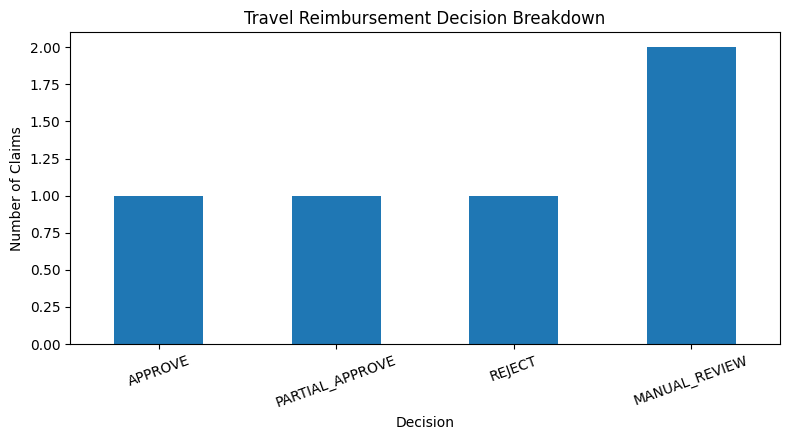

,claim_id,decision,approved_amount,deducted_amount,confidence
0,CLM-001,APPROVE,1110.0,0.0,0.99
1,CLM-002,REJECT,0.0,380.0,0.99
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.98
3,CLM-004,MANUAL_REVIEW,3000.0,0.0,0.90
4,CLM-005,MANUAL_REVIEW,75.0,145.0,0.90


In [16]:

if not results:
    raise RuntimeError(
        "No claim results are available. "
        "Run the 'Process All Claims' cell successfully before running the dashboard."
    )

df_results = pd.DataFrame(results)

required_columns = {
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "confidence"
}

missing_columns = required_columns - set(df_results.columns)

if missing_columns:
    raise RuntimeError(
        f"Results are missing required columns: {sorted(missing_columns)}\n"
        f"Current columns: {list(df_results.columns)}"
    )

decision_order = [
    "APPROVE",
    "PARTIAL_APPROVE",
    "REJECT",
    "MANUAL_REVIEW"
]

decision_counts = (
    df_results["decision"]
    .value_counts()
    .reindex(decision_order, fill_value=0)
)

total_claimed = sum(
    float(claim["total_claimed"])
    for claim in SAMPLE_CLAIMS
)

total_approved = float(
    df_results["approved_amount"].sum()
)

total_deducted = float(
    df_results["deducted_amount"].sum()
)

print(f"Total Claims: {len(df_results)}")
print(f"Total Claimed: ${total_claimed:,.2f}")
print(f"Potential / Approved Amount: ${total_approved:,.2f}")
print(f"Policy Deductions: ${total_deducted:,.2f}")

print("\nDecision Breakdown:")
display(decision_counts.to_frame(name="count"))

plt.figure(figsize=(8, 4.5))
decision_counts.plot(kind="bar")
plt.title("Travel Reimbursement Decision Breakdown")
plt.xlabel("Decision")
plt.ylabel("Number of Claims")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display_columns = [
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "confidence"
]

display(df_results[display_columns])


## 10. Basic Evaluation Tests

Expected policy outcomes for the supplied sample claims:
- CLM-001 → `APPROVE`
- CLM-002 → `REJECT`
- CLM-003 → `PARTIAL_APPROVE`
- CLM-004 → `MANUAL_REVIEW`
- CLM-005 → `MANUAL_REVIEW`


In [12]:
EXPECTED_DECISIONS = {
    "CLM-001": "APPROVE",
    "CLM-002": "REJECT",
    "CLM-003": "PARTIAL_APPROVE",
    "CLM-004": "MANUAL_REVIEW",
    "CLM-005": "MANUAL_REVIEW",
}

actual = {row["claim_id"]: row["decision"] for row in results}

for claim_id, expected in EXPECTED_DECISIONS.items():
    observed = actual.get(claim_id)
    status = "PASS" if observed == expected else "FAIL"
    print(f"{status}: {claim_id}: expected={expected}, actual={observed}")

assert actual == EXPECTED_DECISIONS, "One or more policy decisions differ from expected outcomes."

print("All sample decision tests passed")


PASS: CLM-001: expected=APPROVE, actual=APPROVE
PASS: CLM-002: expected=REJECT, actual=REJECT
PASS: CLM-003: expected=PARTIAL_APPROVE, actual=PARTIAL_APPROVE
PASS: CLM-004: expected=MANUAL_REVIEW, actual=MANUAL_REVIEW
PASS: CLM-005: expected=MANUAL_REVIEW, actual=MANUAL_REVIEW

✓ All sample decision tests passed


## 11. Design Notes & Reasoning

### Why this architecture
The implementation intentionally separates **LLM orchestration** from **policy enforcement**.

The OpenAI model:
- interprets each claim
- chooses tools
- sequences tool use
- combines tool outputs into a short reasoning summary

Python:
- enforces policy rules
- performs monetary calculations
- checks dates and receipts
- applies conservative Manual Review precedence
- guarantees the final output schema

### Reliability choices
1. **No LLM arithmetic dependency** — amounts and caps are calculated by Python.
2. **Manual Review is conservative** — missing receipts, non-economy airfare, late claims, high-value claims, unknown categories, and ambiguous mixed-category cases are not forced into an automatic decision.
3. **Fallback checks** — if the model skips a critical tool, the validator executes it deterministically.
4. **Approval threshold uses post-deduction amount** — the final tier check is always recomputed from `apply_limits.approved_total`.
5. **Exact final schema** — the final cell outputs only the assignment-required fields.

### Assumptions / limitations
- The supplied descriptions contain enough information to infer meal days and lodging nights.
- For timeliness, the trip end date is used as the expense date for a claim-level check.
- `approved_amount` in a `MANUAL_REVIEW` result means the amount currently policy-eligible after deterministic caps; it is **not** a final payment authorization.
- This prototype uses an in-memory policy dictionary because the policy is small. A production version could replace this with governed policy retrieval / RAG.
- Duplicate detection was not needed for the five supplied claims and is therefore not implemented.


## 12. FINAL STRUCTURED JSON

**The next cell is intentionally the final code cell.**  
It outputs one object per claim with exactly these required fields:

`claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used`


In [13]:

REQUIRED_FIELDS = [
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "missing_docs",
    "policy_refs",
    "confidence",
    "explanation",
    "tools_used",
]

final_results = [
    {field: result[field] for field in REQUIRED_FIELDS}
    for result in results
]

print(json.dumps(final_results, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-CAT-02",
      "POL-PD-01",
      "POL-PD-02",
      "POL-AIR-01",
      "POL-RCT-01",
      "POL-APR-02",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "APPROVE: all evaluated items comply with policy and required documents are present.",
    "tools_used": [
      "check_eligibility",
      "check_receipts",
      "apply_limits",
      "check_airfare_class",
      "check_timeliness",
      "check_approval_tier"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-CAT-02",
      "POL-AIR-01",
      "POL-RCT-01",
      "POL-APR-01",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "REJECT: 2 item(s) are e